In [1]:
import torch
import os
import pandas as pd
from d2l.mxnet import linreg
%matplotlib inline
import random
from d2l import torch as d2l

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [3]:
x=torch.arange(12)
print(x)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])


In [4]:
print(x.shape)

torch.Size([12])


In [5]:
y=x.reshape(3,2,1,-1)
y


tensor([[[[ 0,  1]],

         [[ 2,  3]]],


        [[[ 4,  5]],

         [[ 6,  7]]],


        [[[ 8,  9]],

         [[10, 11]]]])

In [6]:
torch.tensor([[2, 1, 4, 3], [1, 2, 3, 4], [4, 3, 2, 1]]).shape

torch.Size([3, 4])

In [7]:
x = torch.tensor([[1.0, 2, 4, 8],
                 [1,2,4,8]])
y = torch.tensor([2, 2, 2, 2])
x + y, x - y, x * y, x / y, x ** y  # **运算符是求幂运算

(tensor([[ 3.,  4.,  6., 10.],
         [ 3.,  4.,  6., 10.]]),
 tensor([[-1.,  0.,  2.,  6.],
         [-1.,  0.,  2.,  6.]]),
 tensor([[ 2.,  4.,  8., 16.],
         [ 2.,  4.,  8., 16.]]),
 tensor([[0.5000, 1.0000, 2.0000, 4.0000],
         [0.5000, 1.0000, 2.0000, 4.0000]]),
 tensor([[ 1.,  4., 16., 64.],
         [ 1.,  4., 16., 64.]]))

In [8]:
X = torch.arange(12, dtype=torch.float32).reshape((3,4))
Y = torch.tensor([[2.0, 1, 4, 3], [1, 2, 3, 4], [4, 3, 2, 1]])
torch.cat((X, Y), dim=0), torch.cat((X, Y), dim=1)

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [ 2.,  1.,  4.,  3.],
         [ 1.,  2.,  3.,  4.],
         [ 4.,  3.,  2.,  1.]]),
 tensor([[ 0.,  1.,  2.,  3.,  2.,  1.,  4.,  3.],
         [ 4.,  5.,  6.,  7.,  1.,  2.,  3.,  4.],
         [ 8.,  9., 10., 11.,  4.,  3.,  2.,  1.]]))

In [9]:
x=torch.arange(12, dtype=torch.float32).reshape(3,2,2)
x[0,0]=1
y=torch.arange(12, dtype=torch.float32).reshape(3,2,2)
dim0=torch.cat((x,y),dim=0)
print(f'dim0结果{dim0},\n{dim0.shape}')
dim1=torch.cat((x,y),dim=1)
print(f'dim1结果{dim1},\n{dim1.shape}')
dim2=torch.cat((x,y),dim=2)
print(f'dim2结果{dim2},\n{dim2.shape}')

dim0结果tensor([[[ 1.,  1.],
         [ 2.,  3.]],

        [[ 4.,  5.],
         [ 6.,  7.]],

        [[ 8.,  9.],
         [10., 11.]],

        [[ 0.,  1.],
         [ 2.,  3.]],

        [[ 4.,  5.],
         [ 6.,  7.]],

        [[ 8.,  9.],
         [10., 11.]]]),
torch.Size([6, 2, 2])
dim1结果tensor([[[ 1.,  1.],
         [ 2.,  3.],
         [ 0.,  1.],
         [ 2.,  3.]],

        [[ 4.,  5.],
         [ 6.,  7.],
         [ 4.,  5.],
         [ 6.,  7.]],

        [[ 8.,  9.],
         [10., 11.],
         [ 8.,  9.],
         [10., 11.]]]),
torch.Size([3, 4, 2])
dim2结果tensor([[[ 1.,  1.,  0.,  1.],
         [ 2.,  3.,  2.,  3.]],

        [[ 4.,  5.,  4.,  5.],
         [ 6.,  7.,  6.,  7.]],

        [[ 8.,  9.,  8.,  9.],
         [10., 11., 10., 11.]]]),
torch.Size([3, 2, 4])


In [10]:
x=torch.arange(12, dtype=torch.float32).reshape(3,4)
x[0:2,:]=12
x

tensor([[12., 12., 12., 12.],
        [12., 12., 12., 12.],
        [ 8.,  9., 10., 11.]])

In [11]:
x=torch.arange(12, dtype=torch.float32).reshape(3,2,2)
y=torch.arange(2, dtype=torch.float32).reshape(1,1,2)
x+y

tensor([[[ 0.,  2.],
         [ 2.,  4.]],

        [[ 4.,  6.],
         [ 6.,  8.]],

        [[ 8., 10.],
         [10., 12.]]])

In [12]:

os.makedirs(os.path.join('..', 'data'), exist_ok=True)
data_file = os.path.join('..', 'data', 'house_tiny.csv')
with open(data_file, 'w') as f:
    f.write('NumRooms,Alley,Price\n')  # 列名
    f.write('NA,Pave,127500\n')  # 每行表示一个数据样本
    f.write('2,NA,106000\n')
    f.write('4,NA,178100\n')
    f.write('NA,NA,140000\n')
# print(os.path.abspath(data_file))
data=pd.read_csv(data_file)
print(data)

   NumRooms Alley   Price
0       NaN  Pave  127500
1       2.0   NaN  106000
2       4.0   NaN  178100
3       NaN   NaN  140000


A = torch.arange(24, dtype=torch.float32).reshape(4, 6)
print(A)
A.cumsum(axis=0)
每一行相加

In [13]:
x=torch.arange(5, dtype=torch.float32)
y=torch.arange(25, dtype=torch.float32).reshape(5,5)
z=torch.mv(y,x)
print(x)
print(y)
print(z)

x2=torch.arange(5, dtype=torch.float32).reshape(1,5)
y2=torch.arange(25,dtype=torch.float32).reshape(5,5)
z2=torch.mm(x2,y2)
print('------------------------')
print(x2)
print(y2)
z2

tensor([0., 1., 2., 3., 4.])
tensor([[ 0.,  1.,  2.,  3.,  4.],
        [ 5.,  6.,  7.,  8.,  9.],
        [10., 11., 12., 13., 14.],
        [15., 16., 17., 18., 19.],
        [20., 21., 22., 23., 24.]])
tensor([ 30.,  80., 130., 180., 230.])
------------------------
tensor([[0., 1., 2., 3., 4.]])
tensor([[ 0.,  1.,  2.,  3.,  4.],
        [ 5.,  6.,  7.,  8.,  9.],
        [10., 11., 12., 13., 14.],
        [15., 16., 17., 18., 19.],
        [20., 21., 22., 23., 24.]])


tensor([[150., 160., 170., 180., 190.]])

In [14]:
A=torch.tensor([[2,3,4],[5,6,7]])
A/A.sum(axis=1,keepdims=True)
# A.sum(axis=1)

tensor([[0.2222, 0.3333, 0.4444],
        [0.2778, 0.3333, 0.3889]])

In [63]:
x=torch.arange(1000).reshape(500,2,1)
print(len(x))

500


In [20]:
x=torch.ones(3)
y=x.T
z=torch.dot(x,y)
y

tensor([1., 1., 1.])

In [35]:
x=torch.tensor([0.0,1,2,3,4])
x.requires_grad_(True)

y=2*torch.dot(x,x)
y.backward()

x.grad==4*x
# x.grad.zero_()
# y=x.sum()
# y.backward()
# x.grad

tensor([True, True, True, True, True])

In [37]:


x = torch.tensor([1.0, 2.0], requires_grad=True)
# 动态分支：运算路径随x的值变化
if x[0] > 1.0:
    y = x[0] * x[1] **2
else:
    y = x[0]** 2 * x[1]
y.backward()
x.grad

tensor([4., 1.])

In [42]:

x=torch.tensor([1.0, 2.0,3,4],requires_grad=True)

y=torch.dot(x,x)
y.backward()
x.grad

tensor([2., 4., 6., 8.])

In [47]:
x=torch.tensor([1.0, 2.0,3,4],requires_grad=True)
y=x*x
y.sum().backward()
x.grad

tensor([2., 4., 6., 8.])

features: tensor([-0.8547, -0.5219]) 
label: tensor([4.2579])


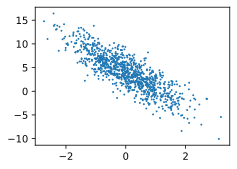

In [56]:
def synthetic_data(w, b, num_examples):  #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
print('features:', features[0],'\nlabel:', labels[0])
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

In [76]:
def synthetic_data(w,b,num_examples):
    # '生成y=Xw+b+噪声'
    X=torch.normal(0,1,(num_examples,len(w)))
    y=torch.matmul(X,w)+b
    y+=torch.normal(0,0.01,y.shape)
    return X,y.reshape((-1,1))

true_w=torch.tensor([2.0,-3.4])
true_b=4.2
features, labels = synthetic_data(true_w, true_b, 1000)

# d2l.set_figsize()
# d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

'读取小批量数据函数'
def data_iter(batch_size,features,labels):
    num_examples=len(features)
    '获取第一维长度'
    indices=list(range(num_examples))
    '创建列表'
    random.shuffle(indices)
    '打乱列表'
    for i in range(0,num_examples,batch_size):
        batch_indices=torch.tensor(indices[i:min(i+batch_size,num_examples)])
        yield features[batch_indices],labels[batch_indices]
        '生成小批量,yield不是返回值函数'
# batch_size=10
# for X,y in data_iter(batch_size,features,labels):
#     print(X,'\n',y)
#     break
#     '调用函数'


w=torch.normal(0.0,0.01,size=(2,1),requires_grad=True)
b=torch.zeros(1,requires_grad=True)
'给定初值'

def linerg(X,w,b):
    return torch.matmul(X,w)+b
'线性回归模型'


def squared_loss(y_hat,y):
    return (y_hat-y.reshape(y_hat.shape))**2/2
'定义均方根损失函数'

def sgd(params,lr,batch_size):
    '优化方法--小批量梯度下降法'
    with torch.no_grad():
        'with方法，进入with代码块时，执行 “上下文对象” 的 “进入操作”；退出代码块时，自动执行 “退出操作”，无需手动控制。'
        '暂停梯度追踪'
        for param in params:
            param-=lr*param.grad/batch_size
            param.grad.zero_()

'训练'
lr=0.03
num_epochs=3
net=linerg
loss=squared_loss
batch_size=10

for epoch in range(num_epochs):
    for X,y in data_iter(batch_size,features,labels):
        l=loss(net(X,w,b),y)
        l.sum().backward()
        sgd([w,b],lr,batch_size)
    with torch.no_grad():
        train_l=loss(net(features,w,b),labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

epoch 1, loss 0.040843
epoch 2, loss 0.000172
epoch 3, loss 0.000054
w的估计误差: tensor([-0.0003, -0.0010], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0008], grad_fn=<RsubBackward1>)
